# Flash Attention -- Complete Interview Guide

## Table of Contents

1. [The Problem: Standard Attention's "Memory Wall"](#1.-The-Problem:-Standard-Attention's-"Memory-Wall")
2. [What is FlashAttention?](#2.-What-is-FlashAttention?)
3. [How Does FlashAttention Work? (The Techniques)](#3.-How-Does-FlashAttention-Work?-(The-Techniques))
4. [Why Use FlashAttention?](#4.-Why-Use-FlashAttention?)
5. [Standard Attention vs. Flash Attention (Detailed)](#2.-Standard-Attention-vs.-Flash-Attention)
6. [IO Complexity Comparison](#6.-IO-Complexity-Comparison)
7. [Flash Attention 1 vs 2 vs 3 -- Evolution](#7.-Flash-Attention-1-vs-2-vs-3----Evolution)
8. [ASCII Diagram: Tiling Strategy](#8.-ASCII-Diagram:-Tiling-Strategy)
9. [PyTorch Code: Using Flash Attention](#9.-PyTorch-Code:-Using-Flash-Attention)
10. [When to Use / When NOT to Use Flash Attention](#10.-When-to-Use-/-When-NOT-to-Use-Flash-Attention)
11. [Ring Attention for Distributed Long-Context](#11.-Ring-Attention-for-Distributed-Long-Context)
12. [Top 8 Flash Attention Interview Q&A](#12.-Top-8-Flash-Attention-Interview-Q&A)
13. [References](#13.-References)


# FlashAttention 

## 1. The Problem: Standard Attention's "Memory Wall"

Standard attention in Transformers, while powerful, hits a significant performance bottleneck, especially with long sequences. Let's revisit the steps and identify the issue:

1.  **Compute Scores:** `P = Q @ K.T`
2.  **Scale:** `P = P / sqrt(d_k)`
3.  **Softmax:** `S = softmax(P)`
4.  **Compute Output:** `O = S @ V`

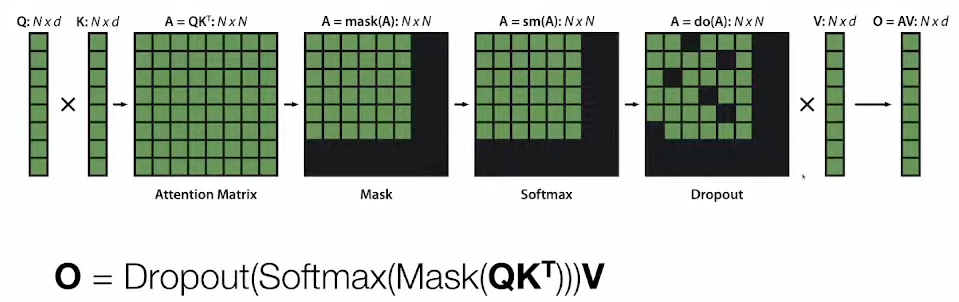

**The Bottleneck - It's About Memory I/O:**

*   **Large Intermediate Matrices:** Steps 1-3 require creating and storing the `P` (scores) and `S` (attention weights) matrices. If the sequence length is `N`, these matrices are **`N x N`**. For long sequences (e.g., N=8192), this matrix becomes *enormous* (8192x8192 requires hundreds of MB or even GBs).
*   **Slow Memory Access (HBM vs. SRAM):**
    *   GPUs have two main types of memory:
        *   **HBM (High Bandwidth Memory):** Large capacity (like a big pantry) but relatively slow access speeds.
        *   **SRAM (Static Random Access Memory):** Very small capacity (like a tiny kitchen countertop) but *extremely* fast access.
    *   Standard attention needs to read `Q`, `K`, `V` from HBM, calculate the huge `P` matrix, write it back to HBM, read `P` back to compute `S`, write `S` to HBM, read `S` and `V` back, compute `O`, and finally write `O` back to HBM.
    
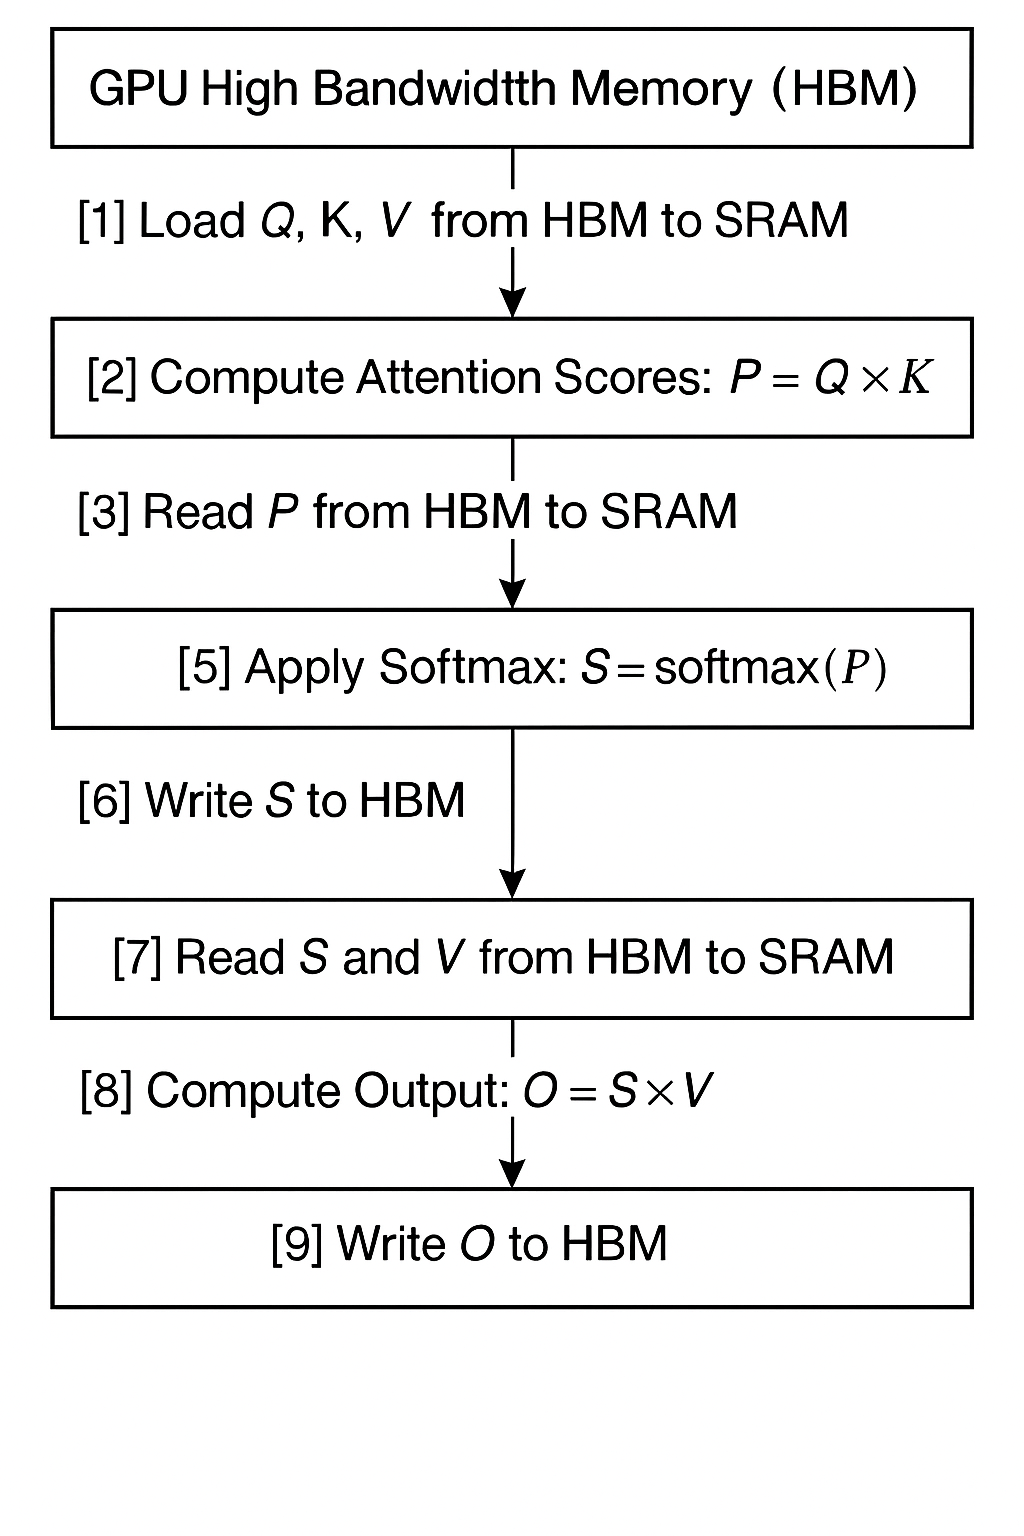

 > The core problem is **not the math (FLOPs)** – GPUs are great at that. `The problem is the **constant, slow back-and-forth data transfer (I/O)**` between the compute units and the large, slow HBM, primarily due to handling the massive `N x N` intermediate matrices. `Standard attention is` **memory-bound**

## 2. What is FlashAttention? 
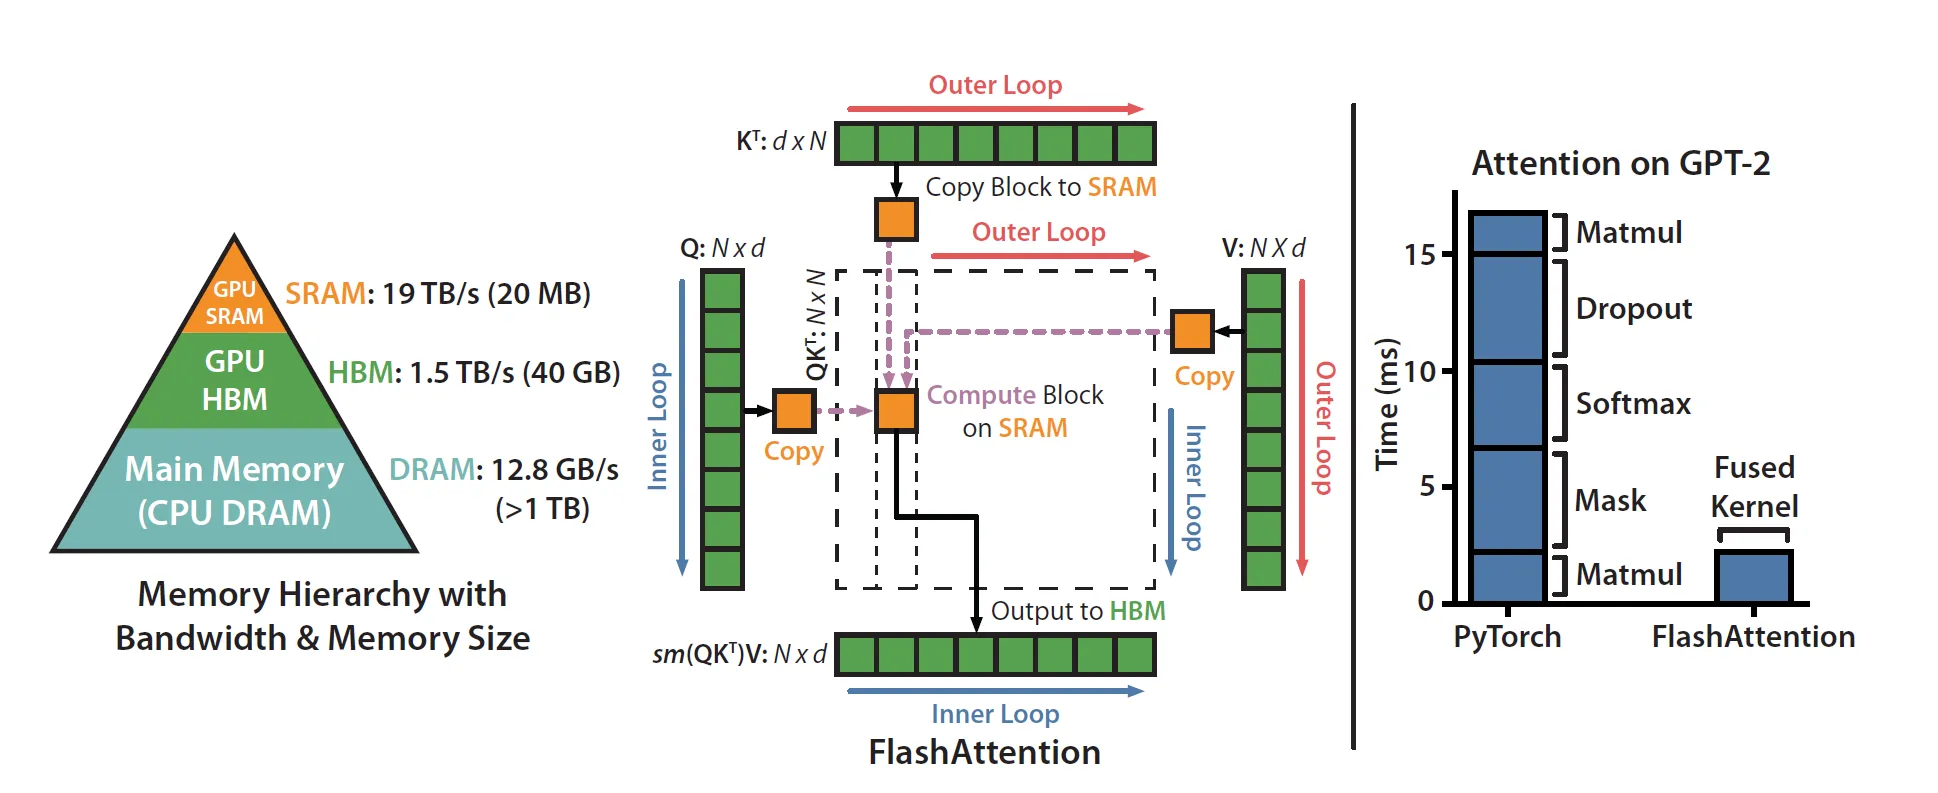

### What is FlashAttention?

FlashAttention is an exact, memory-efficient, and high-speed attention mechanism designed for transformer models. Unlike approximate methods, it computes the full attention without any loss in accuracy. Its primary innovation lies in being **I/O-aware**, meaning it optimizes data movement between different memory hierarchies to enhance performance.

> A100 GPU has **40–80GB** of high bandwidth memory (HBM, the thing that gives you lovely CUDA OOMs) with a bandwidth of **1.5–2.0 TB/s** and **192KB** of on-chip SRAM per each of 108 streaming multiprocessors with bandwidth estimated around **19TB/s.**

## 3. How Does FlashAttention Work? (The Techniques)
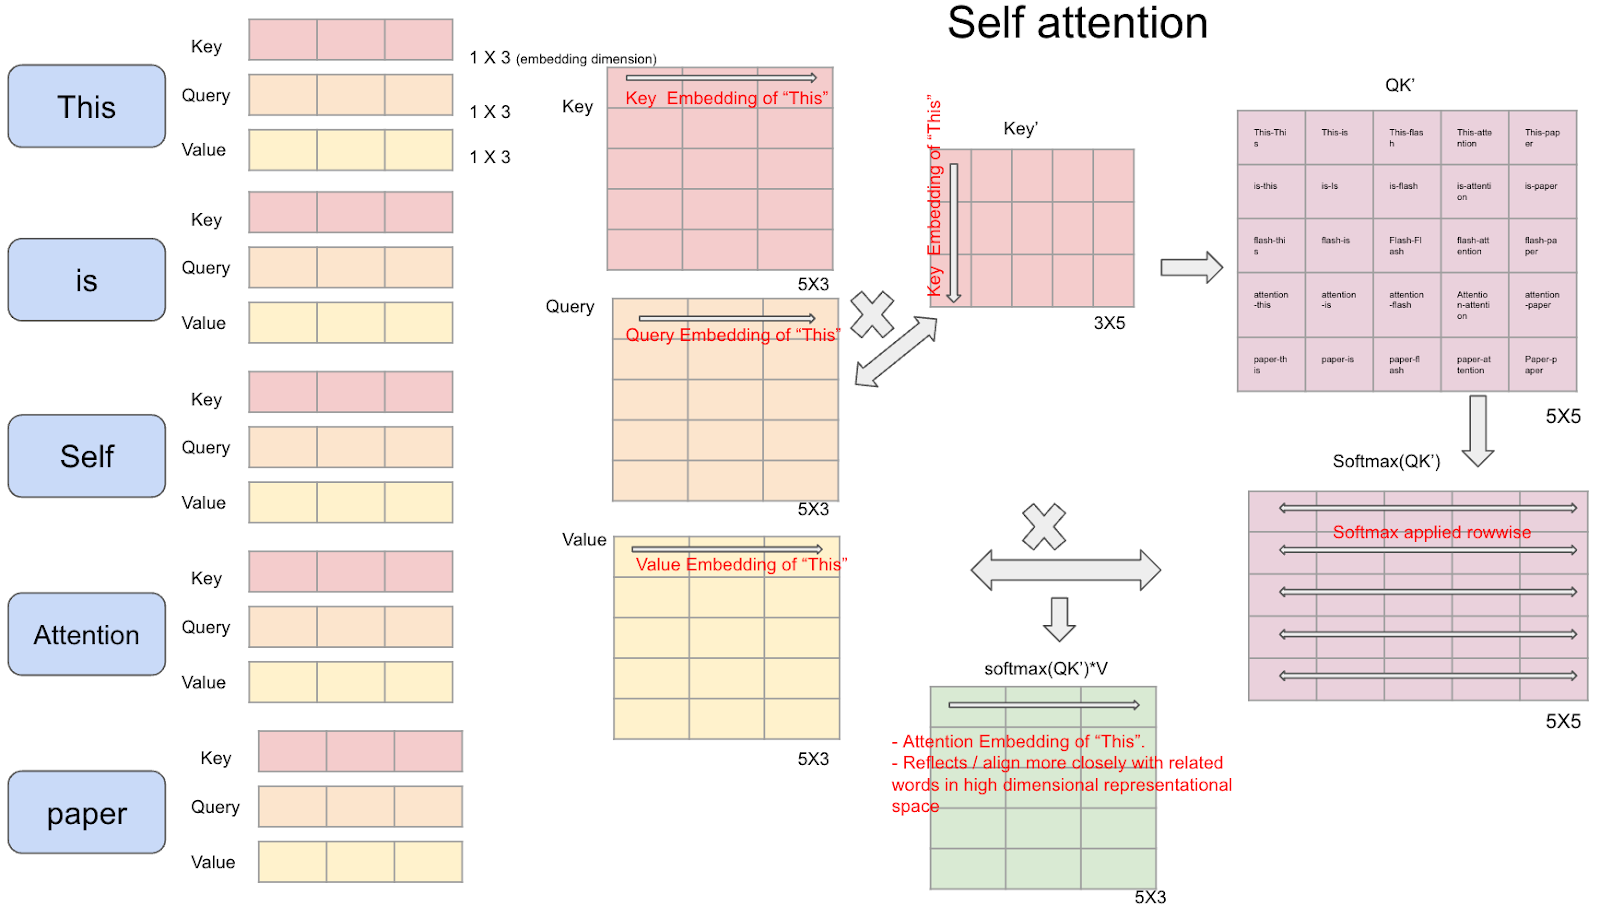
FlashAttention cleverly reorganizes the computation using several key ideas:

1.  **Tiling (Working on the Countertop):**
    *   Instead of loading the whole `Q`, `K`, `V` from the "pantry" (HBM), FlashAttention loads small **blocks (tiles)** of these matrices into the "tiny kitchen countertop" (fast SRAM).
    *   These blocks *are* small enough to fit entirely within the limited but fast SRAM.
2.  **Fused Computation within SRAM:**
	-  Once blocks of `Q`, `K`, and `V` are in SRAM, FlashAttention performs *multiple* steps of the attention calculation (like calculating block-wise scores and applying them to `V_block`) **entirely within the fast SRAM** before writing any intermediate results back to HBM.

	2.1.  **Kernel Fusion:**
	  - FlashAttention fuses many distinct operations (`scaling, masking, softmax, dropout, matrix multiplication`) into a single GPU **kernel** (a program the GPU runs). Launching kernels has overhead; fusing them means the GPU reads the required data from HBM *once*, performs many computations in fast SRAM, and writes the *final* result back to HBM, drastically reducing the slow HBM I/O.
   

3.  **Online Softmax (Clever Normalization):**
    *   Standard softmax needs the *entire* row of the score matrix (`P`) at once to compute the normalization factor (finding the maximum value and the sum of exponentials). This is why it forces the materialization of the `N x N` matrix.
    *   FlashAttention uses a mathematical trick. As it processes blocks of `Q` against blocks of `K` and `V` within SRAM, it keeps track of the **running statistics** needed for the final softmax normalization (specifically, the running maximum score and the running sum of exponentials for the current row of `Q`).
    *   It updates these statistics and correctly scales the intermediate output for each block *iteratively*. When all blocks for a row of `Q` have been processed, the final output block is correctly normalized *as if* the entire row had been seen at once, but **without ever storing the full row or the full `N x N` matrix**.



## 4. Why Use FlashAttention?

*   **Massive Speedup:** By drastically reducing the HBM read/writes and making the computation less memory-bound, FlashAttention is significantly faster (often 2-7x reported, depending on hardware and settings).
*   **Huge Memory Savings:** By *not* storing the `N x N` matrices (`P` and `S`), memory usage plummets. This enables:
    *   Training models on much **longer sequence lengths** (that were previously impossible).
    *   Using **larger batch sizes**, further improving training efficiency.
*   **Exactness:** It's crucial to remember FlashAttention computes the **mathematically identical** result to standard attention. It's an optimization, not an approximation.




## 2. Standard Attention vs. Flash Attention

### Standard Attention

In the seminal transformer paper ("Attention Is All You Need"), the attention mechanism is computed as follows:

$$
\text{Attn}(Q, K, V) = \text{Softmax}\left(\frac{QK^T}{\sqrt{d}}\right)V
$$

- **Input Projections:**  
  The input embeddings are projected into three matrices: Query (\(Q\)), Key (\(K\)), and Value (\(V\)).
- **Computation:**  
  The product \(QK^T\) generates an \(N \times N\) matrix (with \(N\) being the sequence length), and applying softmax row-wise yields the attention probabilities.
- **Complexity Issue:**  
  The full attention matrix requires \(O(N^2)\) memory and many data transfers between high-bandwidth memory (HBM) and fast on-chip SRAM, which makes it impractical for long sequences.

### Flash Attention

Flash Attention addresses these limitations through an IO-aware design that minimizes unnecessary memory transfers and leverages the GPU’s memory hierarchy.

- **Tiling:**  
  Instead of computing and storing the entire \(N \times N\) attention matrix, the algorithm partitions the Q, K, and V matrices into smaller blocks (tiles) that fit into fast SRAM.
  
  - **Result:**  
    Memory complexity drops from \(O(N^2)\) to \(O(N)\), as each tile is processed independently.
  
- **Partial Computation and Accumulation:**  
  For each tile:
  - **Dot Product:**  
    Compute partial scores:  
    $$
    S_{i,j} = \frac{Q_i K_j^T}{\sqrt{d}}
    $$
  - **Local Softmax:**  
    Instead of a single softmax across the whole row, the softmax is computed per tile. Local statistics such as the maximum value (\(m_i\)) and sum of exponentials (\(l_i\)) are maintained.
  - **Re-normalization:**  
    As new tiles are processed, these statistics are updated using formulas like:
    $$
    m_{\text{new}, i} = \max(m_i, m_{\tilde{i},j})
    $$
    $$
    l_{\text{new}, i} = l_i \cdot e^{m_i - m_{\text{new}, i}} + l_{\tilde{i},j} \cdot e^{m_{\tilde{i},j} - m_{\text{new}, i}}
    $$
    This ensures that the final softmax output is exactly the same as if computed in one go.
  - **Output Accumulation:**  
    The weighted output is accumulated for each block:
    $$
    O_i = \text{diag}(l_i) \cdot \left( O_i \cdot e^{m_i - m_{\text{new}, i}} \right) + P_{\tilde{i},j} \cdot V_j \cdot e^{m_{\tilde{i},j} - m_{\text{new}, i}}
    $$
    where \(P_{\tilde{i},j}\) represents the normalized partial attention weights.
    
- **IO-Aware Execution:**  
  By fusing the operations (dot product, softmax, and weighted sum) into a single GPU kernel, Flash Attention minimizes slow HBM-to-SRAM transfers, significantly boosting speed.

*This design not only accelerates the forward pass but also efficiently recomputes intermediates during backpropagation without storing the full \(N \times N\) matrix.*  


---

## 3. Detailed Comparison

| **Aspect**                | **Standard Attention**                                   | **Flash Attention**                                                 |
|---------------------------|----------------------------------------------------------|----------------------------------------------------------------------|
| **Memory Usage**          | Requires full \(N \times N\) matrix (\(O(N^2)\))         | Processes tiles; memory scales linearly (\(O(N)\))                    |
| **Memory Transfers (IO)** | Frequent transfers between HBM and SRAM                | Fused tiled operations minimize transfers                           |
| **Computation Speed**     | Slower due to memory-bound softmax and matrix materialization | 2–4× faster due to reduced data movement and efficient kernel fusion  |
| **Numerical Accuracy**    | Standard softmax with numerical tricks                 | Maintains exact results using re-normalization and log-sum-exp techniques |
| **Backward Pass**         | Stores full attention for gradient computation         | Recomputes intermediates via saved summary statistics                  |

*Key takeaway:* Flash Attention is especially beneficial for long sequences, reducing both computational time and memory requirements, and is ideal for training large models or real-time inference applications.

citeturn0search5

---

## 4. Usage and Implementation

### When and Where to Use Flash Attention
- **Large Models & Long Sequences:**  
  Essential for training LLMs or running inference on tasks that involve very long contexts.
- **Real-Time Applications:**  
  Reduces latency in applications like chatbots or translation services.
- **Supported Frameworks:**  
  Already integrated into some libraries (e.g., Hugging Face Transformers with a “flash” prefix) and implemented through optimized CUDA kernels or frameworks like Triton.

### Hardware and Software Requirements
- **Modern GPUs:**  
  Requires GPUs with ample HBM and high-speed SRAM (e.g., NVIDIA A100, Hopper series). Older GPUs like the V100 may not fully benefit from these optimizations.
- **Software Tools:**  
  Custom CUDA kernels or higher-level libraries like Triton facilitate the development and integration of Flash Attention into deep learning pipelines.

### Implementation Challenges
- **Kernel Optimization:**  
  Writing and tuning CUDA kernels for efficient tile-based computation can be challenging. Triton helps abstract some of this complexity.
- **Numerical Stability:**  
  Although Flash Attention maintains exactness, careful implementation (such as using BF16) is required to manage potential numerical deviations.
- **Compatibility:**  
  The method may require adaptations for different GPU architectures.

*Real-world performance improvements include up to 70% of the theoretical max FLOPS and practical speedups on models like BERT-large and GPT2.*  
citeturn0search3

---

## 5. How Flash Attention Works: A Step-by-Step Outline

1. **Tiling the Input:**
   - Divide the Q, K, and V matrices into smaller blocks based on the capacity of SRAM.
   - For example, for a sequence length \(N = 1000\) and head dimension \(d\), compute appropriate block sizes \(B_r\) and \(B_c\) to fit the fast memory.

2. **Partial Computations:**
   - For each tile, compute the scaled dot product:
     $$
     S_{i,j} = \frac{Q_i K_j^T}{\sqrt{d}}
     $$
   - Calculate local softmax statistics: determine the maximum value and sum of exponentials for each row.

3. **Re-normalization and Accumulation:**
   - As each tile is processed, update cumulative statistics:
     $$
     m_{\text{new}, i} = \max(m_i, m_{\tilde{i},j})
     $$
     $$
     l_{\text{new}, i} = l_i \cdot e^{m_i - m_{\text{new}, i}} + l_{\tilde{i},j} \cdot e^{m_{\tilde{i},j} - m_{\text{new}, i}}
     $$
   - Accumulate the output using:
     $$
     O_i = \text{diag}(l_i) \cdot \left( O_i \cdot e^{m_i - m_{\text{new}, i}} \right) + P_{\tilde{i},j} \cdot V_j \cdot e^{m_{\tilde{i},j} - m_{\text{new}, i}}
     $$
   - This process ensures that each tile’s contribution is correctly normalized and added to the final output, guaranteeing numerical stability.

4. **Backward Pass:**
   - Instead of storing the entire \(N \times N\) matrix, summary statistics are stored. These are later used to recompute gradients efficiently during backpropagation.

*This step-by-step strategy leverages the GPU’s memory hierarchy by keeping computations in the fast SRAM as much as possible, thereby reducing overall memory access time.*



---

## 6. IO Complexity Comparison

Understanding the HBM (High Bandwidth Memory) access complexity is key to appreciating why FlashAttention is faster, even though both approaches perform the same number of FLOPs.

Let:
- **N** = sequence length
- **d** = head dimension
- **M** = SRAM size (in elements)

| **Metric**                     | **Standard Attention**                          | **FlashAttention**                                      |
|--------------------------------|-------------------------------------------------|---------------------------------------------------------|
| **HBM Reads/Writes**          | O(N*d + N^2)                                    | O(N^2 * d^2 / M)                                       |
| **Explanation**                | Must read Q, K, V (N*d each), write full N x N attention matrix to HBM, read it back for V multiplication, write output | Reads/writes Q, K, V in tiles; never materializes full N x N matrix in HBM. Total HBM access depends on how many tile passes are needed |
| **Memory for Attention Matrix**| O(N^2) -- stores full S = softmax(QK^T/sqrt(d)) | O(N) -- only stores one tile row + running statistics   |
| **Total FLOPs**                | O(N^2 * d)                                      | O(N^2 * d) -- **same** (exact computation)              |
| **Bottleneck**                 | Memory I/O bound                                | Compute bound (the ideal regime for GPUs)               |

**Key Insight:** FlashAttention does NOT reduce computation -- it reduces **memory traffic**. Since M (SRAM size) is typically much larger than d^2, the factor N^2 * d^2 / M is significantly smaller than N^2 + N*d, resulting in far fewer HBM accesses.

> **Interview one-liner:** "Standard attention is memory-bound because it materializes the N x N matrix in HBM. FlashAttention is IO-aware: it tiles Q, K, V into SRAM, fuses all ops in a single kernel, and reduces HBM access from O(N^2) to O(N^2 d^2 / M), making it compute-bound instead."

---

## 7. Flash Attention 1 vs 2 vs 3 -- Evolution

| **Feature / Aspect**            | **FlashAttention-1 (2022)**                        | **FlashAttention-2 (2023)**                                  | **FlashAttention-3 (2024)**                                    |
|---------------------------------|----------------------------------------------------|--------------------------------------------------------------|----------------------------------------------------------------|
| **Paper**                       | Dao et al., "FlashAttention: Fast and Memory-Efficient Exact Attention with IO-Awareness" | Dao, "FlashAttention-2: Faster Attention with Better Parallelism and Work Partitioning" | Shah et al., "FlashAttention-3: Fast and Accurate Attention with Asynchrony and Low-precision" |
| **Core Innovation**             | Tiling + online softmax + kernel fusion             | Better work partitioning, reduced non-matmul FLOPs           | Asynchronous execution, warp specialization, FP8 support       |
| **Target Hardware**             | NVIDIA A100 (Ampere)                                | NVIDIA A100 (Ampere)                                         | NVIDIA H100 (Hopper)                                           |
| **Parallelism Strategy**        | Parallelizes over batch size and number of heads     | Adds parallelism over **sequence length** dimension too; better occupancy on modern GPUs | Exploits Hopper-specific features: TMA (Tensor Memory Accelerator), warp-group specialization |
| **Non-matmul FLOP Reduction**   | Baseline                                            | Reduces non-matmul FLOPs (rescaling, softmax bookkeeping) which are 4x slower on tensor cores | Further reduces via low-precision paths                        |
| **Precision Support**           | FP16, BF16                                          | FP16, BF16                                                   | FP16, BF16, **FP8** (new!)                                     |
| **Speed vs Standard Attention** | ~2-4x faster                                        | ~2x faster than FA-1 (~5-9x vs standard)                    | ~1.5-2x faster than FA-2 on Hopper                            |
| **FLOPS Utilization**           | ~30-50% of A100 peak                                | ~50-73% of A100 peak                                         | Up to ~75% of H100 peak (FP8: even higher)                    |
| **Causal Masking Optimization** | Basic support                                       | Improved -- skips unnecessary blocks in causal attention      | Further optimized for causal patterns                          |
| **Backward Pass**               | Recomputation from saved statistics                 | More efficient recomputation, better memory access patterns   | Async overlap of backward computation                          |
| **Software Approach**           | Hand-written CUDA kernels                           | Hand-written CUDA kernels, more optimized                    | CUDA + Hopper-specific PTX instructions, uses CUTLASS 3.x     |

### Key Takeaways for Interviews:
- **FA-1 to FA-2:** The jump was about **parallelism and work partitioning** -- FA-1 left GPU SMs underutilized for long sequences because it only parallelized over batch and heads. FA-2 also parallelizes over the sequence dimension and reduces overhead from non-matmul operations.
- **FA-2 to FA-3:** The jump was about **hardware-specific optimization for Hopper GPUs** -- exploiting asynchronous execution (overlap data loading with computation), warp specialization (different warps do different jobs), and FP8 support for even higher throughput.

---

## 8. ASCII Diagram: Tiling Strategy

This diagram shows how FlashAttention loads small blocks of Q, K, V into SRAM instead of the full matrices.

```
                         FULL Q, K, V matrices in HBM (slow, large)
    ┌─────────────────────────────────────────────────────────────────┐
    │                                                                 │
    │   Q  [N x d]            K^T  [d x N]           V  [N x d]      │
    │   ┌──┬──┬──┬──┐        ┌──┬──┬──┬──┐        ┌──┬──┬──┬──┐     │
    │   │Q0│Q1│Q2│Q3│        │K0│K1│K2│K3│        │V0│V1│V2│V3│     │
    │   ├──┼──┼──┼──┤        ├──┼──┼──┼──┤        ├──┼──┼──┼──┤     │
    │   │Q4│Q5│Q6│Q7│        │K4│K5│K6│K7│        │V4│V5│V6│V7│     │
    │   └──┴──┴──┴──┘        └──┴──┴──┴──┘        └──┴──┴──┴──┘     │
    │                                                                 │
    └──────────────────────────┬──────────────────────────────────────┘
                               │
                    Load tiles │ (one block at a time)
                               ▼
    ┌─────────────────────────────────────────────────────────────────┐
    │                    SRAM (fast, tiny ~192KB)                      │
    │                                                                 │
    │   Step 1: Load Q_block_i, K_block_j, V_block_j                 │
    │   ┌────────┐   ┌────────┐   ┌────────┐                         │
    │   │ Q_i    │   │ K_j^T  │   │ V_j    │                         │
    │   │[Br x d]│   │[d x Bc]│   │[Bc x d]│                         │
    │   └───┬────┘   └───┬────┘   └───┬────┘                         │
    │       │             │             │                              │
    │       ▼             ▼             │                              │
    │   Step 2: S_ij = Q_i @ K_j^T / sqrt(d)    (in SRAM!)           │
    │   ┌────────────┐                  │                              │
    │   │ S_ij       │                  │                              │
    │   │ [Br x Bc]  │                  │                              │
    │   └─────┬──────┘                  │                              │
    │         │                         │                              │
    │         ▼                         │                              │
    │   Step 3: Online softmax          │                              │
    │   - Update running max (m_i)      │                              │
    │   - Update running sum (l_i)      │                              │
    │   - P_ij = exp(S_ij - m_new)      │                              │
    │   ┌────────────┐                  │                              │
    │   │ P_ij       │                  │                              │
    │   │ [Br x Bc]  │                  │                              │
    │   └─────┬──────┘                  │                              │
    │         │                         │                              │
    │         ▼                         ▼                              │
    │   Step 4: O_i += P_ij @ V_j   (accumulate in SRAM!)            │
    │   ┌────────────┐                                                │
    │   │ O_i        │  (rescaled with new running stats)             │
    │   │ [Br x d]   │                                                │
    │   └────────────┘                                                │
    │                                                                 │
    │   Repeat for next K_block, V_block (j+1, j+2, ...)             │
    └──────────────────────────┬──────────────────────────────────────┘
                               │
                    Write final│ O_i block back to HBM
                               ▼
    ┌─────────────────────────────────────────────────────────────────┐
    │  HBM: Output O [N x d]                                         │
    │  ┌──────────┐                                                   │
    │  │ O_i done │  (move to next Q_block: i+1)                     │
    │  └──────────┘                                                   │
    └─────────────────────────────────────────────────────────────────┘

OUTER LOOP: for each Q_block_i  (i = 0, 1, ..., N/Br - 1)
  INNER LOOP: for each K_block_j, V_block_j  (j = 0, 1, ..., N/Bc - 1)
    1. Load Q_i, K_j, V_j into SRAM
    2. Compute S_ij = Q_i @ K_j^T / sqrt(d)
    3. Update online softmax stats (m_i, l_i)
    4. Accumulate O_i += softmax(S_ij) @ V_j
  END INNER
  Write O_i to HBM
END OUTER
```

**Why this works:** The key insight is that `Br` and `Bc` are chosen so that `Q_i` (Br x d) + `K_j` (Bc x d) + `V_j` (Bc x d) + `S_ij` (Br x Bc) + `O_i` (Br x d) all fit in SRAM simultaneously. The N x N attention matrix is never materialized in HBM.

In [ ]:
## 9. PyTorch Code: Using Flash Attention
## PyTorch >= 2.0 provides FlashAttention via scaled_dot_product_attention (SDPA)

import torch
import torch.nn.functional as F

# ----- Example: Using PyTorch's built-in Flash Attention -----

# Simulate inputs: (batch_size, num_heads, seq_len, head_dim)
batch_size, num_heads, seq_len, head_dim = 2, 8, 1024, 64

Q = torch.randn(batch_size, num_heads, seq_len, head_dim, dtype=torch.float16, device="cuda")
K = torch.randn(batch_size, num_heads, seq_len, head_dim, dtype=torch.float16, device="cuda")
V = torch.randn(batch_size, num_heads, seq_len, head_dim, dtype=torch.float16, device="cuda")

# Method 1: Let PyTorch auto-select the best backend (recommended)
# It will use FlashAttention if hardware supports it (Ampere+, FP16/BF16)
with torch.backends.cuda.sdp_kernel(
    enable_flash=True,      # Enable FlashAttention backend
    enable_math=False,       # Disable vanilla math backend
    enable_mem_efficient=False  # Disable memory-efficient (xformers-style) backend
):
    output = F.scaled_dot_product_attention(Q, K, V)
    print(f"Output shape: {output.shape}")  # [2, 8, 1024, 64]

# Method 2: With causal mask (for autoregressive / decoder models)
with torch.backends.cuda.sdp_kernel(enable_flash=True, enable_math=False, enable_mem_efficient=False):
    output_causal = F.scaled_dot_product_attention(Q, K, V, is_causal=True)
    print(f"Causal output shape: {output_causal.shape}")

# Method 3: Using HuggingFace Transformers with Flash Attention 2
# from transformers import AutoModelForCausalLM
# model = AutoModelForCausalLM.from_pretrained(
#     "meta-llama/Llama-2-7b-hf",
#     torch_dtype=torch.float16,
#     attn_implementation="flash_attention_2"  # <-- key argument
# )

print("\nKey notes:")
print("- Requires NVIDIA GPU with compute capability >= 8.0 (Ampere: A100, RTX 3090+)")
print("- Input must be FP16 or BF16 (not FP32)")
print("- Head dimension must be <= 256 and divisible by 8")
print("- PyTorch >= 2.0 required for SDPA; install flash-attn package for latest features")

---

## 10. When to Use / When NOT to Use Flash Attention

### USE Flash Attention When:

| Scenario | Why It Helps |
|----------|-------------|
| **Long sequences (N > 512)** | Memory savings grow quadratically; the longer the sequence, the bigger the win |
| **Training LLMs** | Enables larger batch sizes + longer contexts within the same GPU memory budget |
| **Inference with long context** | Faster time-to-first-token and lower memory footprint |
| **You need exact attention** | Unlike sparse/linear attention approximations, FlashAttention is mathematically exact |
| **Multi-head attention with FP16/BF16** | This is the sweet spot for FlashAttention's kernel optimizations |
| **Using Ampere+ GPUs (A100, H100, RTX 3090+)** | Required hardware for the optimized CUDA kernels |

### DO NOT Use Flash Attention When:

| Scenario | Why Not |
|----------|---------|
| **Very short sequences (N < 128)** | Overhead of tiling setup may exceed the benefit; standard attention is fast enough |
| **Older GPUs (V100, T4, RTX 2080)** | Compute capability < 8.0; FlashAttention kernels won't run or fall back to slower paths |
| **FP32 required** | FlashAttention requires FP16 or BF16 inputs; if you cannot use mixed precision, it won't work |
| **Custom attention patterns (non-standard masks)** | FlashAttention supports causal and no-mask well, but complex custom masks may not be supported |
| **You need the attention weight matrix itself** | FlashAttention never materializes the N x N matrix; if you need to visualize or extract attention weights, use standard attention |
| **Cross-attention with very different Q/KV lengths** | Some implementations have constraints on sequence length ratios |
| **CPU-only environments** | FlashAttention is a CUDA kernel optimization; no CPU support |

### Decision Flowchart (Mental Model):

```
Is your GPU Ampere or newer (sm_80+)?
  ├── NO  --> Use standard attention or xformers memory-efficient attention
  └── YES
      Is your input FP16 or BF16?
        ├── NO  --> Cast to FP16/BF16 if acceptable, else use standard attention
        └── YES
            Is sequence length > ~256?
              ├── NO  --> Standard attention is likely fine (marginal benefit)
              └── YES
                  Do you need the raw attention weight matrix?
                    ├── YES --> Use standard attention (FA doesn't materialize it)
                    └── NO  --> USE FLASH ATTENTION
```

---

## 11. Ring Attention for Distributed Long-Context

**Ring Attention** (Liu et al., 2023) extends FlashAttention's tiling idea across **multiple GPUs/devices** to handle extremely long sequences that don't fit in a single GPU's memory.

### Core Idea:
- The sequence is **split across devices** along the sequence dimension (each device holds a chunk of Q, K, V).
- Devices are arranged in a **logical ring** topology.
- Each device computes attention for its local Q block against a local K, V block, then **passes K, V blocks to the next device** in the ring.
- After N_devices steps, every Q block has seen every K, V block -- full exact attention is computed.

### How It Combines with FlashAttention:
```
Device 0          Device 1          Device 2          Device 3
[Q0, K0, V0]     [Q1, K1, V1]     [Q2, K2, V2]     [Q3, K3, V3]
    │                 │                 │                 │
    │  FlashAttn      │  FlashAttn      │  FlashAttn      │  FlashAttn
    │  Q0 x K0,V0     │  Q1 x K1,V1     │  Q2 x K2,V2     │  Q3 x K3,V3
    │                 │                 │                 │
    └──── pass K0,V0 ─┘──── pass K1,V1 ─┘──── pass K2,V2 ─┘──── pass K3,V3 ──┐
    ┌─────────────────────────────────────────────────────────────────────────┘
    │  (ring rotation: each device gets the next K,V block)
    │  Repeat until all K,V blocks have been seen by all Q blocks
```

### Key Benefits:
- **Scales to millions of tokens** -- e.g., 1M+ context windows used in Gemini, Claude, etc.
- Communication (passing K, V) is **overlapped** with computation (FlashAttention on current block) -- near-linear scaling.
- Maintains **exact attention** -- no approximation.
- Compatible with FlashAttention's tiling and online softmax within each device.

### Practical Use:
- Ring Attention is used in production systems for ultra-long-context LLMs.
- Implementations exist in JAX (original paper) and are being adopted in PyTorch-based frameworks.
- Often combined with **sequence parallelism** in Megatron-LM style training.

---

## 12. Top 8 Flash Attention Interview Q&A

### Q1: What problem does FlashAttention solve?
**A:** Standard attention is memory-bound, not compute-bound. It wastes time shuttling the huge N x N attention matrix between slow HBM and fast SRAM. FlashAttention eliminates this by tiling Q, K, V into SRAM-sized blocks, computing attention tile-by-tile with online softmax, and never materializing the full N x N matrix in HBM. Same math, fewer memory transfers, 2-7x faster.

---

### Q2: Is FlashAttention an approximation?
**A:** No. FlashAttention computes the mathematically **exact same result** as standard attention. It uses the online softmax trick (tracking running max and sum of exponentials) to get identical outputs without ever forming the full attention matrix. It is purely an IO/memory optimization, not an approximation.

---

### Q3: What is "online softmax" and why is it needed?
**A:** Standard softmax requires seeing the entire row to compute max and normalization. Online softmax processes one tile at a time: it maintains a running maximum (m) and running sum of exponentials (l), updating them as each new tile is processed. Previous partial results are rescaled using the difference between old and new max values. This allows tile-by-tile processing while producing identical results to full-row softmax.

---

### Q4: What is the IO complexity of FlashAttention vs standard attention?
**A:** Standard attention: O(N*d + N^2) HBM accesses -- dominated by reading/writing the N x N attention matrix. FlashAttention: O(N^2 * d^2 / M) where M is SRAM size. Since M >> d^2 on modern GPUs, this is significantly less. Both do O(N^2 * d) FLOPs -- FlashAttention just moves less data.

---

### Q5: What are the main differences between FlashAttention-1, 2, and 3?
**A:**
- **FA-1 (2022):** Introduced tiling + online softmax + kernel fusion. Parallelized over batch and heads only.
- **FA-2 (2023):** Added sequence-length parallelism, reduced non-matmul FLOPs (4x slower on tensor cores), ~2x faster than FA-1.
- **FA-3 (2024):** Targets Hopper GPUs (H100) with asynchronous execution, warp specialization, and FP8 support. ~1.5-2x faster than FA-2 on Hopper.

---

### Q6: Why can't FlashAttention return attention weights?
**A:** The N x N attention weight matrix is never materialized in HBM -- that is the whole point of the optimization. Each tile's softmax output is immediately multiplied with V and accumulated into the output. If you need attention weights (e.g., for visualization), you must use standard attention.

---

### Q7: What hardware does FlashAttention require?
**A:** NVIDIA GPUs with compute capability >= 8.0 (Ampere architecture: A100, RTX 3090/4090, and newer). Inputs must be FP16 or BF16. FA-3 specifically targets Hopper (H100) GPUs. Older GPUs (V100, T4) lack the required hardware features. PyTorch >= 2.0 provides FlashAttention through `scaled_dot_product_attention`.

---

### Q8: What is Ring Attention and how does it relate to FlashAttention?
**A:** Ring Attention distributes long sequences across multiple GPUs arranged in a ring. Each GPU holds a chunk of Q, K, V and computes local FlashAttention. K, V blocks are passed around the ring so every Q chunk eventually attends to all K, V chunks. Communication overlaps with computation, enabling million-token contexts with near-linear scaling. It builds on FlashAttention's tiling and online softmax within each device.

---

## 13. References

1. **FlashAttention (FA-1):** Dao, T., Fu, D.Y., Ermon, S., Rudra, A., & Re, C. (2022). *"FlashAttention: Fast and Memory-Efficient Exact Attention with IO-Awareness."* NeurIPS 2022. [arXiv:2205.14135](https://arxiv.org/abs/2205.14135)

2. **FlashAttention-2 (FA-2):** Dao, T. (2023). *"FlashAttention-2: Faster Attention with Better Parallelism and Work Partitioning."* ICLR 2024. [arXiv:2307.08691](https://arxiv.org/abs/2307.08691)

3. **FlashAttention-3 (FA-3):** Shah, J., Bikshandi, G., Zhang, Y., Thakkar, V., Ramani, P., & Dao, T. (2024). *"FlashAttention-3: Fast and Accurate Attention with Asynchrony and Low-precision."* [arXiv:2407.08691](https://arxiv.org/abs/2407.08691)

4. **Ring Attention:** Liu, H., Zaharia, M., & Abbeel, P. (2023). *"Ring Attention with Blockwise Transformers for Near-Infinite Context."* [arXiv:2310.01889](https://arxiv.org/abs/2310.01889)

5. **Online Softmax:** Milakov, M., & Gimelshein, N. (2018). *"Online normalizer calculation for softmax."* [arXiv:1805.02867](https://arxiv.org/abs/1805.02867)

6. **PyTorch SDPA Documentation:** [pytorch.org/docs/stable/generated/torch.nn.functional.scaled_dot_product_attention.html](https://pytorch.org/docs/stable/generated/torch.nn.functional.scaled_dot_product_attention.html)

7. **flash-attn GitHub:** [github.com/Dao-AILab/flash-attention](https://github.com/Dao-AILab/flash-attention)